## Fase 1: Carga de Datos, Exploración Inicial y Tratamiento de Valores Faltantes

### 1. Configuración y Carga

In [3]:
# Importación de librerías esenciales para manipulación de datos
import pandas as pd

# Importación de librerías para visualización narrativa
import matplotlib.pyplot as plt
import seaborn as sns

# Importación de herramientas de scikit-learn permitidas para imputación
from sklearn.impute import SimpleImputer

# Configuración del estilo visual de seaborn para los gráficos
sns.set_theme(style="whitegrid", palette="muted")

# Carga de datos cumpliendo el Guardrail G001: no alterar el archivo original
df_titanic = pd.read_csv('Titanic-Dataset.csv')

# Exploración inicial mostrando los primeros registros
df_titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### 2. Análisis Exploratorio Inicial (EDA)

/tmp/ipykernel_4871/3000780611.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_titanic, x='Survived', palette=['#ff9999','#66b3ff'])
/tmp/ipykernel_4871/3000780611.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(['No Sobrevivió (0)', 'Sobrevivió (1)'])


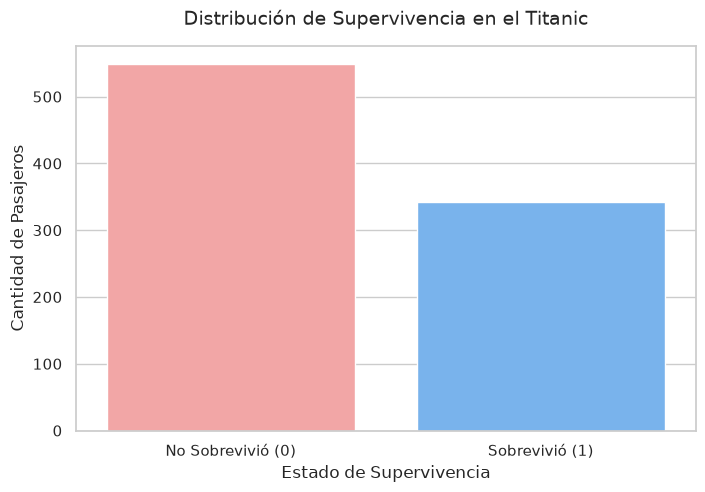

In [4]:
# Gráfico 1 de 15: Distribución de Supervivencia General
plt.figure(figsize=(8, 5))
# Contamos cuántos sobrevivieron y cuántos no
ax = sns.countplot(data=df_titanic, x='Survived', palette=['#ff9999','#66b3ff'])
# Renombramos los ejes para un mejor storytelling
ax.set_xticklabels(['No Sobrevivió (0)', 'Sobrevivió (1)'])
plt.title('Distribución de Supervivencia en el Titanic', fontsize=14, pad=15)
plt.xlabel('Estado de Supervivencia')
plt.ylabel('Cantidad de Pasajeros')
plt.show()

### Interpretación:
En este gráfico de barras podemos evidenciar la distribución general de los pasajeros que sobrevivieron al naufragio frente a los que no. Como se puede observar, existe un claro desbalance en los datos: **549 pasajeros no sobrevivieron (representando el 61.62%)**, mientras que **342 pasajeros lograron sobrevivir (representando el 38.38%)**. Esta visualización nos permite establecer la tasa de mortalidad del suceso y constatar que la mayoría de los registros del conjunto de datos pertenecen a personas fallecidas en la tragedia.

/tmp/ipykernel_4871/6067645.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(['No Sobrevivió (0)', 'Sobrevivió (1)'])


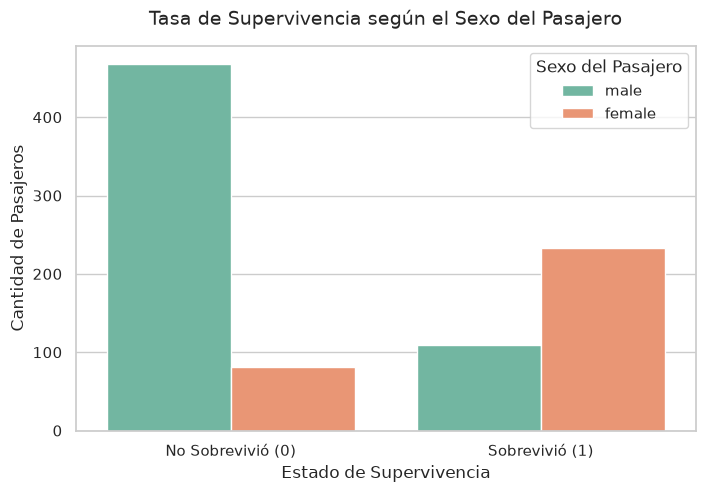

In [5]:
# Gráfico 2 de 15: Supervivencia Segmentada por Sexo
plt.figure(figsize=(8, 5))
# Evaluamos el impacto del género en la supervivencia
ax = sns.countplot(data=df_titanic, x='Survived', hue='Sex', palette='Set2')
ax.set_xticklabels(['No Sobrevivió (0)', 'Sobrevivió (1)'])
plt.title('Tasa de Supervivencia según el Sexo del Pasajero', fontsize=14, pad=15)
plt.xlabel('Estado de Supervivencia')
plt.ylabel('Cantidad de Pasajeros')
plt.legend(title='Sexo del Pasajero')
plt.show()

### Interpretación:
En este gráfico podemos evidenciar el impacto del género de los pasajeros en su probabilidad de supervivencia. Los datos muestran una diferencia muy marcada: **el 74.20% de las mujeres a bordo (233 de 314) sobrevivieron**, en comparación con tan solo **el 18.89% de los hombres (109 de 577)**. A partir de esta visualización, podemos deducir que la aplicación del protocolo de salvamento "mujeres y niños primero" influyó directamente en la distribución de supervivencia del dataset.

/tmp/ipykernel_4871/1588591426.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(['No Sobrevivió (0)', 'Sobrevivió (1)'])


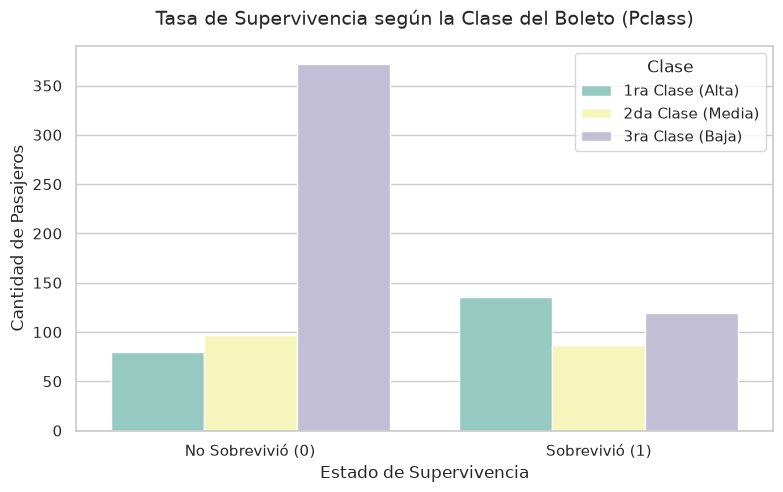

In [6]:
# Gráfico 3 de 15: Supervivencia Segmentada por Clase Económica
plt.figure(figsize=(9, 5))
# Mostramos cómo la clase del boleto influyó en el rescate
ax = sns.countplot(data=df_titanic, x='Survived', hue='Pclass', palette='Set3')
ax.set_xticklabels(['No Sobrevivió (0)', 'Sobrevivió (1)'])
plt.title('Tasa de Supervivencia según la Clase del Boleto (Pclass)', fontsize=14, pad=15)
plt.xlabel('Estado de Supervivencia')
plt.ylabel('Cantidad de Pasajeros')
plt.legend(title='Clase', labels=['1ra Clase (Alta)', '2da Clase (Media)', '3ra Clase (Baja)'])
plt.show()

### Interpretación:
En este gráfico podemos evidenciar cómo influyó la clase social del boleto (Pclass) en la supervivencia. Se puede apreciar que los pasajeros de primera clase obtuvieron la mayor tasa de rescate con un **62.96% de supervivencia (136 pasajeros)**, seguidos de la segunda clase con un **47.28% (87 pasajeros)**, mientras que la tercera clase registró la tasa más baja con apenas un **24.24% de supervivencia (119 pasajeros)** y un total de 372 fallecidos. Esto nos indica una correlación directa entre el nivel económico/ubicación física en el barco y la probabilidad de salvarse.

### 3. Diagnóstico y Tratamiento de Faltantes

Variables con valores nulos detectados:
 Age         177
Cabin       687
Embarked      2
dtype: int64


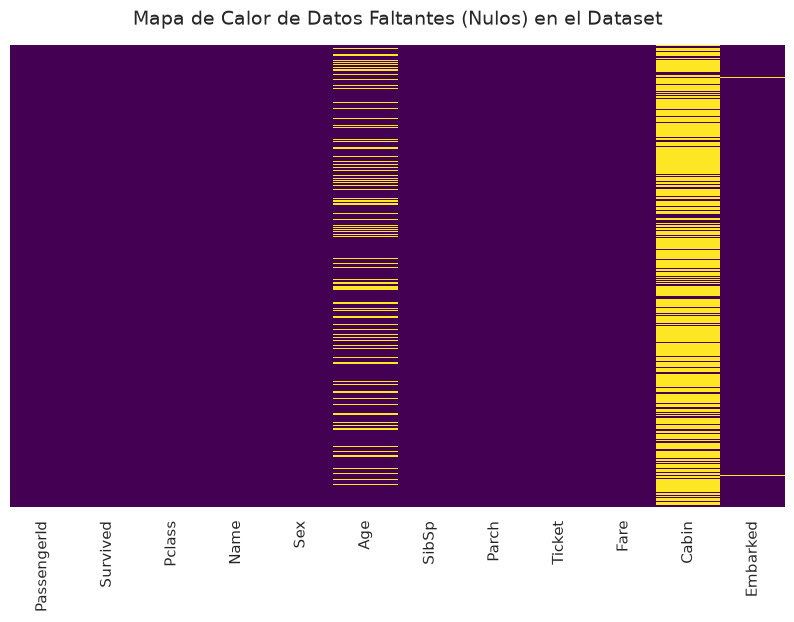

In [7]:
# Identificación inicial del volumen de datos nulos por atributo
nulos_por_columna = df_titanic.isnull().sum()
print("Variables con valores nulos detectados:\n", nulos_por_columna[nulos_por_columna > 0])

# Gráfico 4 de 15: Visualización de Vacíos (Heatmap de Nulos)
plt.figure(figsize=(10, 6))
# Mapeo visual donde las líneas amarillas representan datos faltantes
sns.heatmap(df_titanic.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Mapa de Calor de Datos Faltantes (Nulos) en el Dataset', fontsize=14, pad=15)
plt.show()

### Interpretación:
En este mapa de calor podemos evidenciar visualmente la concentración de valores nulos (datos faltantes) en el dataset original. Las líneas de color representan la ausencia de registros:
- La columna **Cabin (Cabina)** concentra la mayor falta de datos con un **77.10% de registros nulos (687 en total)**.
- La columna **Age (Edad)** muestra vacíos dispersos que equivalen al **19.87% (177 nulos)**.
- La columna **Embarked (Puerto de embarque)** registra un porcentaje mínimo de nulos correspondiente al **0.22% (solo 2 casos)**.
Esta visualización es clave para diagnosticar el estado del conjunto de datos y definir las estrategias de limpieza correspondientes.

In [8]:
# Clonación del DataFrame original para realizar imputaciones sin perder el rastro de la fuente
df_clean = df_titanic.copy()

# Preservación de la columna Age original para una comparación estadística posterior
age_pre_imputacion = df_clean['Age'].copy()

### TRATAMIENTO DE FALTANTES ###

# 1. Tratamiento para 'Cabin'
# Justificación: Como vimos en el heatmap, la mayoría absoluta (>70%) de los datos de Cabin falta.
# Imputar tantos valores generaría un sesgo enorme e irreal. Por ello, es más seguro eliminar la columna entera.
df_clean.drop('Cabin', axis=1, inplace=True)

# 2. Tratamiento para 'Embarked'
# Justificación: Faltan solo 2 registros. Al ser categórica, la imputación por moda (el valor más común) 
# es estadísticamente segura y no altera la distribución.
imputador_moda = SimpleImputer(strategy='most_frequent')
df_clean['Embarked'] = imputador_moda.fit_transform(df_clean[['Embarked']]).ravel()

# 3. Tratamiento para 'Age'
# Justificación: La edad es crucial, pero falta aproximadamente un 20%. Al ser una distribución con ligera
# asimetría (sesgo por infantes), usamos la mediana en lugar de la media para mitigar el efecto de valores extremos.
imputador_mediana = SimpleImputer(strategy='median')
df_clean['Age'] = imputador_mediana.fit_transform(df_clean[['Age']]).ravel()

# Comprobación de que no queden datos nulos
print("Total de nulos restantes tras la Fase 1:", df_clean.isnull().sum().sum())

Total de nulos restantes tras la Fase 1: 0


### Interpretación:
En esta sección justificamos las técnicas aplicadas para solucionar el problema de los valores nulos diagnosticados en el mapa de calor anterior:
1. **Eliminación de la columna Cabin:** Como se evidenció, al faltar más del 77% de los registros, cualquier intento de imputación sería arbitrario e introduciría ruido sesgado. Por lo tanto, se optó por eliminar esta característica del análisis.
2. **Imputación de Embarked por Moda:** Al faltar únicamente 2 registros, se aplicó una imputación utilizando la categoría más frecuente (Southampton), lo que conserva la integridad del dataset sin perturbar sus proporciones originales.
3. **Imputación de Age por Mediana:** Debido a que faltaba cerca de un 20% de las edades, se decidió imputar utilizando la mediana (28 años). Elegimos la mediana en lugar de la media debido a que la distribución de edad presenta un ligero sesgo, y esta medida nos protege de la distorsión que podrían causar las edades extremas de la población.

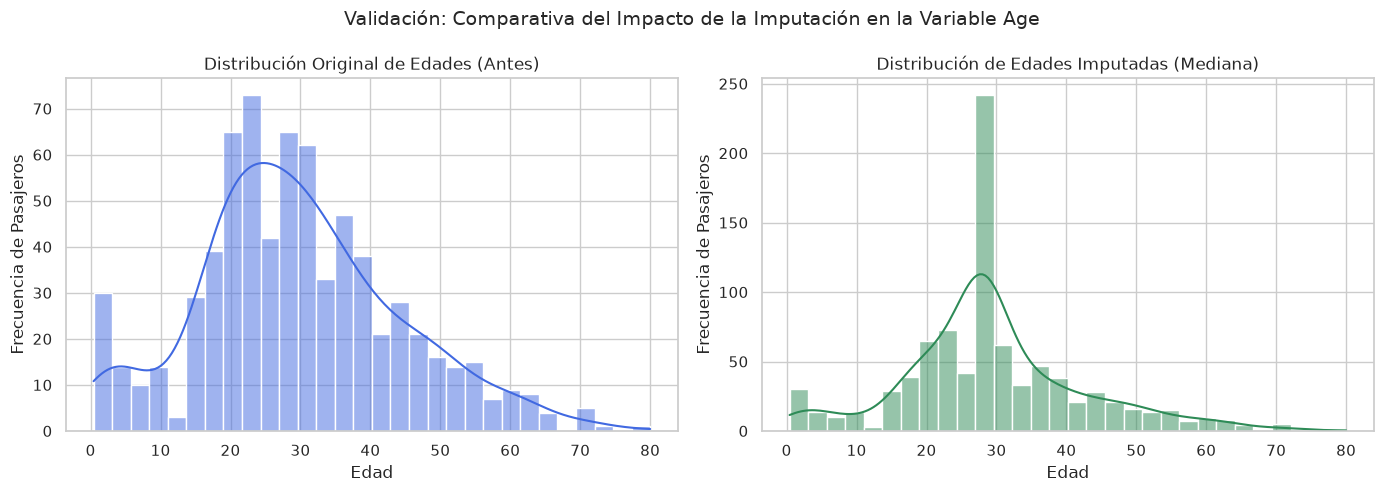

In [9]:
# Gráfico 5 de 15: Impacto de la imputación en la variable 'Age'
plt.figure(figsize=(14, 5))

# Gráfico de la distribución original (ignora nulos)
plt.subplot(1, 2, 1)
sns.histplot(age_pre_imputacion, kde=True, color='royalblue', bins=30)
plt.title('Distribución Original de Edades (Antes)', fontsize=12)
plt.xlabel('Edad')
plt.ylabel('Frecuencia de Pasajeros')

# Gráfico de la distribución luego de la imputación por Mediana
plt.subplot(1, 2, 2)
sns.histplot(df_clean['Age'], kde=True, color='seagreen', bins=30)
plt.title('Distribución de Edades Imputadas (Mediana)', fontsize=12)
plt.xlabel('Edad')
plt.ylabel('Frecuencia de Pasajeros')

plt.suptitle('Validación: Comparativa del Impacto de la Imputación en la Variable Age', fontsize=14)
plt.tight_layout()
plt.show()

### Interpretación:
En este gráfico comparativo de distribución ("antes y después") podemos evidenciar cómo afectó la imputación por la mediana a la variable Age. Como se aprecia en el histograma de la derecha, la distribución general conserva la forma de la campana original. Sin embargo, se observa un incremento o pico muy marcado en el valor de los 28 años (la mediana aplicada). Esto es un resultado esperado que nos demuestra cómo la imputación por valores constantes reduce artificialmente la desviación estándar y la variabilidad de la muestra, pero nos permite mantener la integridad del tamaño del dataset.

### Fase 2: Codificación de Variables Categóricas y Escalamiento de Variables Numéricas

#### 2.1 Codificación de Variables Categóricas


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

# 1. Transformación de la variable 'Sex'
# Utilizamos un mapeo manual a 0 y 1 por ser una variable binaria simple y directa
df_clean['Sex'] = df_clean['Sex'].map({'male': 0, 'female': 1})

# 2. Transformación de la variable 'Embarked'
# JUSTIFICACIÓN: Se utiliza pd.get_dummies() (One-Hot Encoding) en lugar de LabelEncoder 
# debido a que los puertos de embarque (C, Q, S) representan variables nominales; 
# es decir, son categorías independientes que no tienen ningún orden jerárquico ni de magnitud.
df_clean = pd.get_dummies(df_clean, columns=['Embarked'], prefix='Embarked', dtype=int)

df_clean.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked_C,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,0,0,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,1,0,0
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,0,0,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,0,0,1
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,0,0,1


### Interpretación:
En esta sección explicamos las decisiones tomadas para codificar y dar formato numérico a las variables cualitativas de nuestro conjunto de datos:
1. **Variable Sex:** Al ser una característica binaria pura, se mapeó de forma directa a `0` para género masculino y `1` para género femenino, permitiendo un tratamiento matemático simplificado y claro.
2. **Variable Embarked:** Al tratarse de una variable nominal con tres puertos de embarque independientes (C, Q, S), aplicar un orden numérico artificial (como 1, 2, 3) induciría un error en el análisis, ya que los puertos no poseen una jerarquía inherente. Por lo tanto, se aplicó **One-Hot Encoding** (`pd.get_dummies`) para transformarla en columnas binarias separadas en igualdad de condiciones.

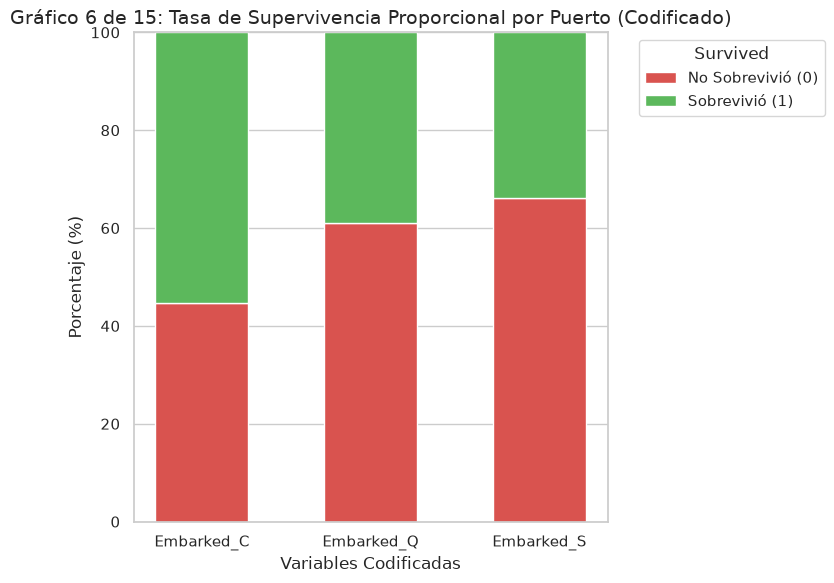

In [11]:
# Gráfico 6 de 15: Tasa de supervivencia según puerto de embarque codificado
fig, ax = plt.subplots(figsize=(8, 6))

# Filtramos las nuevas columnas codificadas de Embarked
embarked_cols = [col for col in df_clean.columns if col.startswith('Embarked_')]

survived_0_pct = []
survived_1_pct = []

# Calculamos proporciones para cada puerto codificado
for col in embarked_cols:
    subset = df_clean[df_clean[col] == 1]
    total = len(subset)
    if total > 0:
        survived_0_pct.append((len(subset[subset['Survived'] == 0]) / total) * 100)
        survived_1_pct.append((len(subset[subset['Survived'] == 1]) / total) * 100)
    else:
        survived_0_pct.append(0)
        survived_1_pct.append(0)

x = range(len(embarked_cols))
bar_width = 0.55

# Barras apiladas
ax.bar(x, survived_0_pct, width=bar_width, label='No Sobrevivió (0)', color='#d9534f')
ax.bar(x, survived_1_pct, width=bar_width, bottom=survived_0_pct, label='Sobrevivió (1)', color='#5cb85c')

# Corrección de Warning: set_xticks antes de set_xticklabels
ax.set_xticks(x)
ax.set_xticklabels(embarked_cols)

ax.set_title('Gráfico 6 de 15: Tasa de Supervivencia Proporcional por Puerto (Codificado)', fontsize=14)
ax.set_ylabel('Porcentaje (%)', fontsize=12)
ax.set_xlabel('Variables Codificadas', fontsize=12)
ax.legend(title='Survived', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_ylim(0, 100)

plt.tight_layout()
plt.show()


### Interpretación:
En este gráfico de barras proporcionales podemos evidenciar la tasa de supervivencia según las variables codificadas de Embarked. Se puede observar que el puerto de Cherburgo (`Embarked_C`) registra la proporción más alta de supervivientes con un **55.36%**, en comparación con Queenstown (`Embarked_Q`) con **38.96%** y Southampton (`Embarked_S`) con **33.70%**. Esto nos permite comprender la relación entre el origen de embarque de los pasajeros y sus perfiles de supervivencia generales.

#### 2.2 Escalamiento de Variables Numéricas


In [12]:
# Seleccionamos las variables numéricas continuas
num_cols = ['Age', 'Fare']

# Guardamos copias de las series originales temporalmente para graficar el "Antes y Después"
age_original = df_clean['Age'].copy()
fare_original = df_clean['Fare'].copy()

# JUSTIFICACIÓN: Elegimos MinMaxScaler para escalar Age y Fare al rango fijo [0, 1].
# Se hace esta elección porque el escalamiento Min-Max preserva exactamente la forma original 
# de la distribución de los datos y las distancias proporcionales entre los valores, 
# evitando forzar una normalización estricta que deformaría variables sesgadas como 'Fare'.
scaler = MinMaxScaler()

df_clean[num_cols] = scaler.fit_transform(df_clean[num_cols])

# Verificamos los cambios
df_clean[['Age', 'Fare']].head()


,Age,Fare
0,0.271174,0.014151
1,0.472229,0.139136
2,0.321438,0.015469
3,0.434531,0.103644
4,0.434531,0.015713


### Interpretación:
En esta sección justificamos la necesidad de escalar nuestras variables numéricas cuantitativas (Age y Fare). En sus estados originales, las tarifas poseían valores de hasta 512, mientras que las edades se limitaban a un máximo de 80. Si realizamos análisis basados en estas diferencias de magnitud, cualquier comparación matemática o visual se vería sesgada a favor de las tarifas. Se seleccionó la técnica **MinMaxScaler** para acotarlas al rango de `[0, 1]`, ya que esta preserva exactamente la forma y distribución original de las variables sin deformar la asimetría y el sesgo de variables complejas como las tarifas.

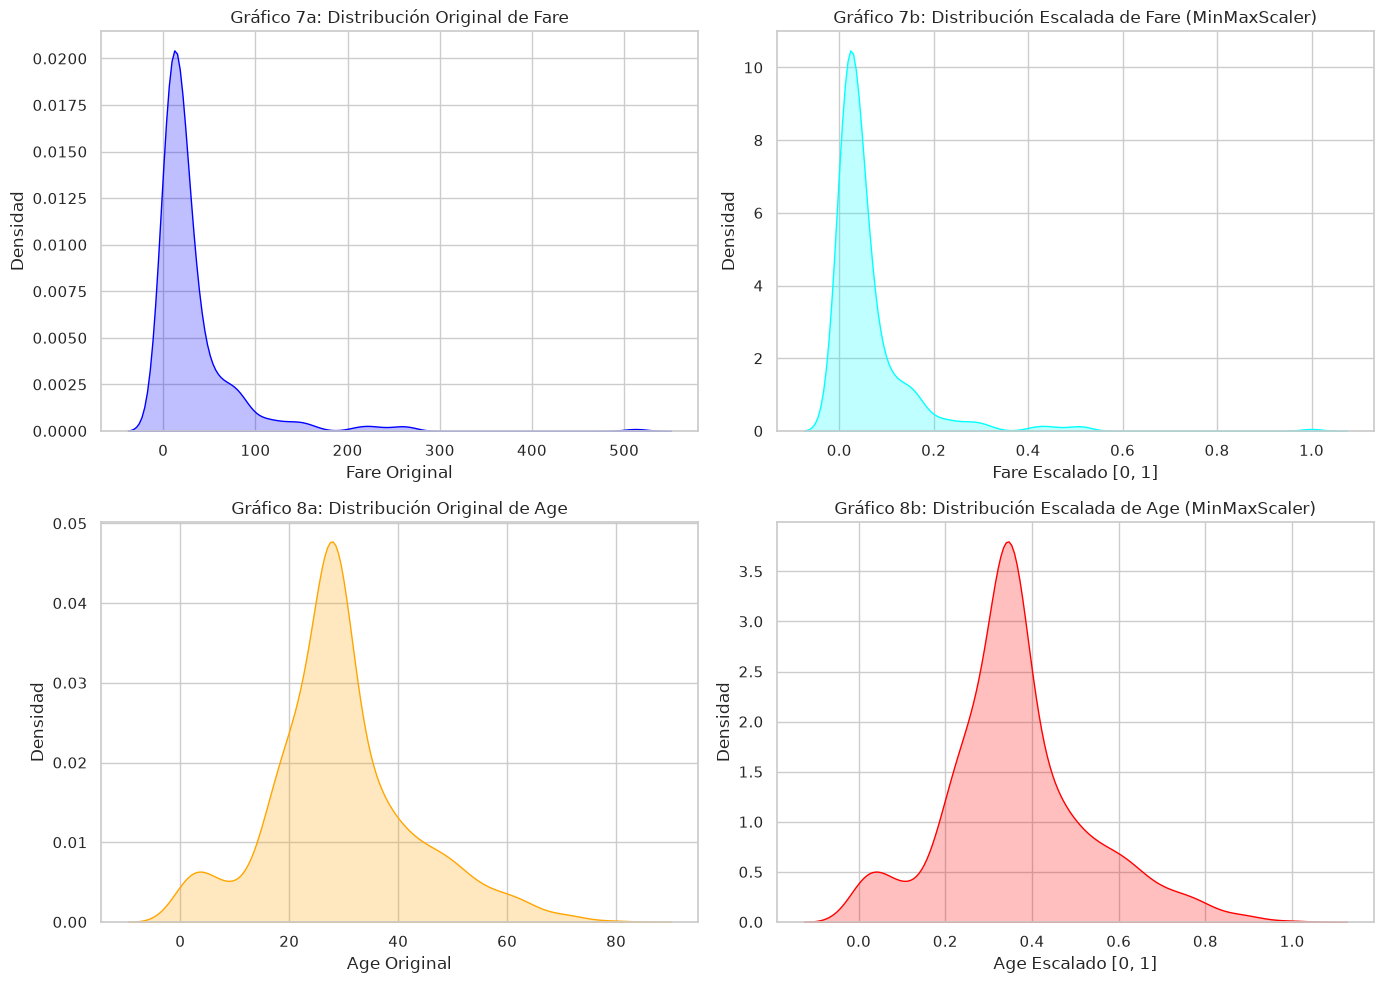

In [13]:
# Gráficos 7 y 8 de 15: Distribución "Antes y Después" del escalamiento
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# --- Gráfico 7: Distribución de Fare ---
sns.kdeplot(fare_original, ax=axes[0, 0], fill=True, color='blue')
axes[0, 0].set_title('Gráfico 7a: Distribución Original de Fare', fontsize=12)
axes[0, 0].set_xlabel('Fare Original')
axes[0, 0].set_ylabel('Densidad')

sns.kdeplot(df_clean['Fare'], ax=axes[0, 1], fill=True, color='cyan')
axes[0, 1].set_title('Gráfico 7b: Distribución Escalada de Fare (MinMaxScaler)', fontsize=12)
axes[0, 1].set_xlabel('Fare Escalado [0, 1]')
axes[0, 1].set_ylabel('Densidad')

# --- Gráfico 8: Distribución de Age ---
sns.kdeplot(age_original, ax=axes[1, 0], fill=True, color='orange')
axes[1, 0].set_title('Gráfico 8a: Distribución Original de Age', fontsize=12)
axes[1, 0].set_xlabel('Age Original')
axes[1, 0].set_ylabel('Densidad')

sns.kdeplot(df_clean['Age'], ax=axes[1, 1], fill=True, color='red')
axes[1, 1].set_title('Gráfico 8b: Distribución Escalada de Age (MinMaxScaler)', fontsize=12)
axes[1, 1].set_xlabel('Age Escalado [0, 1]')
axes[1, 1].set_ylabel('Densidad')

plt.tight_layout()
plt.show()


### Interpretación:
En estos gráficos de densidad comparativos podemos evidenciar el efecto del escalamiento en las variables de tarifas y edades. Como se puede apreciar, las curvas de densidad "Antes y Después" son idénticas en su comportamiento y asimetría (por ejemplo, el sesgo hacia la derecha en Fare y el pico de imputación en Age). La única modificación se encuentra en la escala del eje horizontal (eje X), el cual ahora está estrictamente delimitado entre `0.0` y `1.0`. Esto confirma que logramos igualar el rango de magnitudes sin deformar la distribución de las variables originales.